In [45]:
import os 
import sys
module_path = "compiled_python_modules/"
sys.path.append(module_path)

import numpy as np
import matplotlib.pyplot as plt

from general_python_module import *

### Load relevant variables

In [46]:
MJ_tab_6 = load_MJ_tab_6() # conventional order of amino acids given by num_to_letter_map variable
hamiltonian_walks_contacts=load_hamiltonian_walks_contacts()
hamiltonian_walks_max_abs_GE=load_hamiltonian_walks_max_abs_GE()
hamiltonian_walks_i1_i2=load_hamiltonian_walks_maGE_loop_i1_i2()
hamiltonian_walks_maGE_thread_is_N=load_hamiltonian_walks_maGE_thread_is_N()


In [47]:
path_with_dicts="data/wl_results/struct_006222/seq_ASDMCICDCGWRGSRADCFFRLGMWFM"
list_of_dict=[v for v in os.listdir(path_with_dicts) if 'results_dict' in v]


all_final_raw_ln_g_E=[]
all_bin_has_been_visited=[]

all_saved_conformations=[]
all_saved_conformations_contacts=[]
all_saved_conformations_n_native_contacts=[]

required_flatness_checks=18
for dict_fname in list_of_dict:
    now_dict=np.load(os.path.join(path_with_dicts,dict_fname),\
    allow_pickle=True,).item()
    list_of_repetitions_done=[l for l in now_dict.keys() if isinstance(l, int)]
    for i_repetition in list_of_repetitions_done:
        history_flat_ln_g_E=now_dict[i_repetition]['history_flat_ln_g_E']
        bin_has_been_visited=now_dict[i_repetition]['bin_has_been_visited']
        inds_non_zeros=np.argwhere(history_flat_ln_g_E.sum(axis=0)>0)[:,0]
        if len(inds_non_zeros)>required_flatness_checks:
            final_ln_g_E=history_flat_ln_g_E[:,inds_non_zeros[-1]]
            all_final_raw_ln_g_E.append(final_ln_g_E)
            all_bin_has_been_visited.append(bin_has_been_visited)
            all_saved_conformations.append(
                now_dict[i_repetition]['saved_conformations']
            )
            all_saved_conformations_contacts.append(
                now_dict[i_repetition]['saved_conformations_contacts']
            )
            all_saved_conformations_n_native_contacts.append(
                now_dict[i_repetition]['saved_conformations_n_native_contacts']
            )

            
    energy_bin_centers=now_dict['energy_bin_centers']
    energy_bin_measures=now_dict['energy_bin_measures']

    # assuming leftmost bin contains only the native state
    for ii in range(len(all_final_raw_ln_g_E)):
        all_final_raw_ln_g_E[ii]=all_final_raw_ln_g_E[ii]-all_final_raw_ln_g_E[ii][bin_has_been_visited.astype(np.bool_)][0]

    all_final_raw_ln_g_E=np.array(all_final_raw_ln_g_E)
    all_final_g_E = np.exp(all_final_raw_ln_g_E)

    mean_g_E=all_final_g_E.mean(axis=0)
    std_g_E=all_final_g_E.std(axis=0)

all_saved_conformations=np.array(all_saved_conformations)
all_saved_conformations_contacts=np.array(all_saved_conformations_contacts)
all_saved_conformations_n_native_contacts=np.array(all_saved_conformations_n_native_contacts)

Text(0, 0.5, 'number of structures')

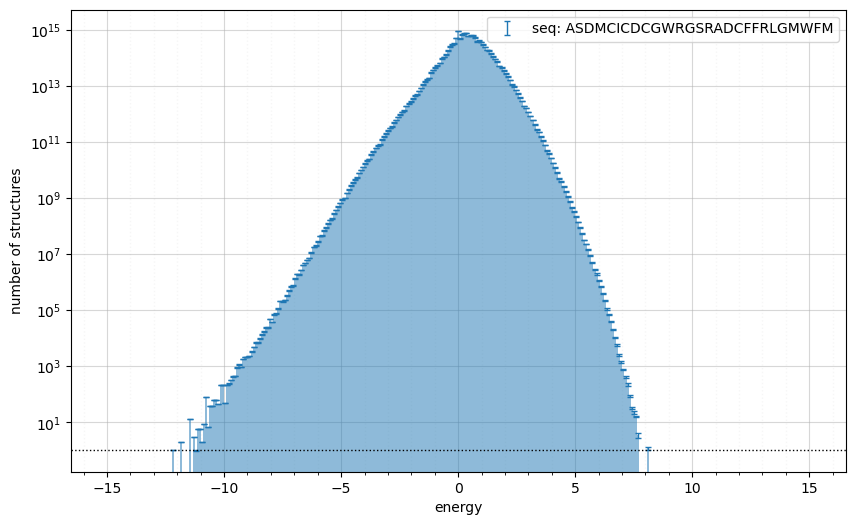

In [64]:
fig,ax=plt.subplots(figsize=(10,6))
ax.grid(alpha=0.5, which='both')
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)
ax.minorticks_on()
ax.set_axisbelow(True)

# ax.errorbar(energy_bin_centers, mean_g_E, 
#         yerr=std_g_E, fmt='+', markersize=5.0, markeredgewidth=1.0, capsize=4.0, 
#         elinewidth=1.0,errorevery=1,label=f"seq: {path_with_dicts.split('seq_')[1]:}")

ax.errorbar(energy_bin_centers, mean_g_E, 
        yerr=std_g_E, fmt='_', markersize=0.0, markeredgewidth=1.0, capsize=2.0, 
        elinewidth=1.0,errorevery=1,label=f"seq: {path_with_dicts.split('seq_')[1]:}")

# ax.step(energy_bin_centers, mean_g_E, where='mid')
ax.bar(energy_bin_centers, mean_g_E, width=energy_bin_measures, 
       align='center', alpha=0.5)

ax.axhline(1,c='k',lw=1.0,ls=':')
ax.legend()
ax.set_yscale('log')
ax.set_xlabel('energy')
ax.set_ylabel('number of structures')


In [49]:
n_repetitions,n_bonds,n_conformations_per_bin,n_bins=all_saved_conformations.shape
all_unique_saved_conformations_numbers=[]
for i_bin in range(n_bins):
    if (all_saved_conformations[...,i_bin]==0).mean()==1:
        all_unique_saved_conformations_numbers.append(0)

    else:
        now_conformations=all_saved_conformations[0,:,:,i_bin]
        for i_rep in range(1,n_repetitions):
            now_conformations=np.concatenate(
                (now_conformations,all_saved_conformations[i_rep,:,:,i_bin]),axis=1
            )
        now_unique_conformations=np.unique(now_conformations,axis=1)
        all_unique_saved_conformations_numbers.append(now_unique_conformations.shape[1])


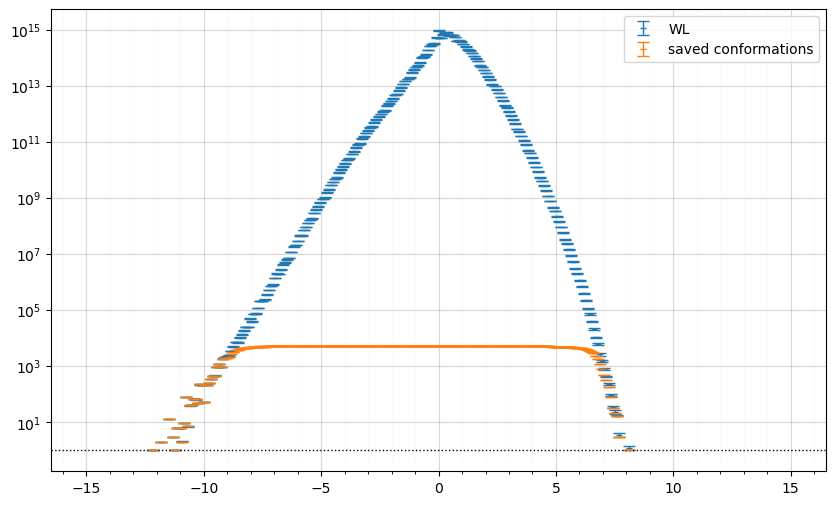

In [52]:
fig,ax=plt.subplots(figsize=(10,6))
ax.grid(alpha=0.5, which='both')
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)
ax.minorticks_on()
ax.set_axisbelow(True)

ax.errorbar(energy_bin_centers, mean_g_E, 
        yerr=std_g_E, fmt='_', markersize=5.0, markeredgewidth=1.0, capsize=4.0, 
        elinewidth=1.0,errorevery=1,label=f"WL")

ax.errorbar(energy_bin_centers, all_unique_saved_conformations_numbers, 
        yerr=0, fmt='_', markersize=5.0, markeredgewidth=1.0, capsize=4.0, 
        elinewidth=1.0,errorevery=1,label=f"saved conformations")


ax.axhline(1,c='k',lw=1.0,ls=':')
ax.legend()
ax.set_yscale('log')

